# Experiment 06: Range Bounding of a Single Layer

In this experiment we create a single layer of a neural network and use verified computing and AMIE polynomials to range bound the layer over a given domain.  This experiment is used to develop a prototype for a function which will range bound a given neural network layer when passed an interval vector as input.


## Imports and Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import get_alpha_coefs
from prism.prism_math.polynomials import convert_sparse_to_dense_polynomial
from prism.networks.ffnn import FFNN

from verified_computing.intvmath import \
    Interval, \
    IntervalColumnVector, \
    left_multiply_interval_column_vector_by_matrix, \
    add_real_vector_to_interval_column_vector

from verified_computing.taylorm import TaylorModel

import experiment_utils

## Get Coefficient Tables

In [2]:

(alpha_relu_coefs,
 alpha_relu_exponents,
 alpha_relu_coefs_float64) = get_alpha_coefs(
    load_file='../prism/src/prism/coefs/relu_vmax7_bigm25_coefs_2021-01-23_20-03-01-218272.pickle')

alpha_relu_struct = experiment_utils.AlphaCoefsStruct(
    alpha_relu_coefs, alpha_relu_exponents, alpha_relu_coefs_float64)

(alpha_tanh_coefs,
 alpha_tanh_exponents,
 alpha_tanh_coefs_float64) = get_alpha_coefs(
    load_file='../prism/src/prism/coefs/tanh_vmax7_bigm25_coefs_2021-01-23_20-00-15-944616.pickle')

alpha_tanh_struct = experiment_utils.AlphaCoefsStruct(
    alpha_tanh_coefs, alpha_tanh_exponents, alpha_tanh_coefs_float64)

alpha_dict = {
    'relu': alpha_relu_struct,
    'tanh': alpha_tanh_struct
}

## Set up Some Common Parameters

Set up some basic parameters for the experiment.

In [3]:
weight_decay = 0.01
m_max = 25

## Create and Train Simple Neural Networks

Here we create and train some simple neural networks to be range bounded.


In [4]:
# Instantiate the networks
relu_net = FFNN(
    net_type='relu',
    n_inputs=2, n_hidden=3, lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam',
    weight_decay=weight_decay)

tanh_net = FFNN(
    net_type='tanh',
    n_inputs=2, n_hidden=3, lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam',
    weight_decay=weight_decay)



## Bound a Layer as an Example

Here we work out an example of how a layer can be range bounded.


In [5]:
# Convert the coefficients from a sparse to a
# dense representation

e = np.array(alpha_tanh_exponents)
p = alpha_tanh_coefs_float64

dense_coefs_tanh = convert_sparse_to_dense_polynomial(
    alpha_tanh_coefs_float64,
    np.array(alpha_tanh_exponents)
)

<class 'matplotlib.axes._subplots.AxesSubplot'>


<AxesSubplot:title={'center':'T(x)'}, xlabel='x'>

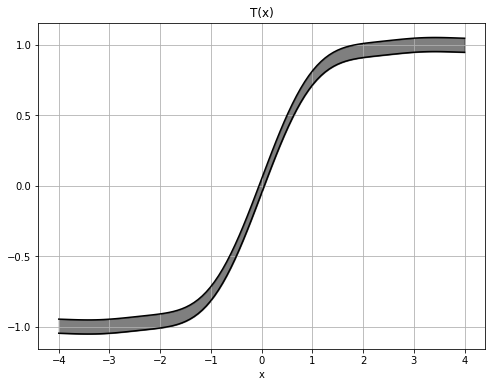

In [6]:
# Get a Taylor model of the activation
t_tanh = TaylorModel(dense_coefs_tanh, -0.05, 0.05)

t_tanh.plot(-4, 4, n_points=100)

In [7]:
# Get the inputs to this layer
x = IntervalColumnVector([Interval(-1, 1)]*2)

print('x = ')
x.print()
print()

# Get the weights and biases for this layer
b1 = tanh_net.get_b1()
w1 = tanh_net.get_w1()

print('b1 = ')
print(b1)
print()

print('w1 = ')
print(w1)
print()

# Compute the value, v, at input to the activation
w_times_x = left_multiply_interval_column_vector_by_matrix(
    w1, x
)

v = add_real_vector_to_interval_column_vector(
    b1, w_times_x
)

print('v = ')
v.print()
print()

# Evaluate the activation to get the layer output
y = t_tanh.bound_interval_vector(v, n_subdomains=10)

print('y = ')
y.print()
print()

x = 
[
  [-1, 1]
  [-1, 1]
]

b1 = 
[[-0.11310548]
 [-0.33866063]
 [-0.35531336]]

w1 = 
[[-0.18197441  0.6799585 ]
 [ 0.03569305  0.39093262]
 [-0.5566075   0.3919111 ]]

v = 
[
  [[-0.9750384], [0.74882746]]
  [[-0.7652863], [0.08796504]]
  [[-1.3038319], [0.5932052]]
]

y = 
[
  [[-0.9004044], [0.7316274]]
  [[-0.72031915], [0.13402288]]
  [[-1.1346105], [0.60479265]]
]




## Perform the Same Bounding Numerically

Here we use brute force evaluation to perform the same range bounding.


In [8]:
x1_sweep = np.linspace(-1, 1, 20)
x2_sweep = np.linspace(-1, 1, 20)

y_list = []

for x1 in x1_sweep:
    for x2 in x2_sweep:
        x = np.array([[x1], [x2]])

        v = w1@x + b1
        y = np.tanh(v)

        y_list.append(y)

y_array = np.hstack(y_list)

lb = np.min(y_array, axis=1)
ub = np.max(y_array, axis=1)

print(lb)
print(ub)


[-0.75091004 -0.64418015 -0.86270638]
[0.63444891 0.08773885 0.53219691]


In [9]:
a = np.array([[1, 2, 3], [1, 2, 3], [1, 2, 3]])
b = np.array([[1], [2], [3]])

c = a@b

print(a)
print(b)
print(c)

[[1 2 3]
 [1 2 3]
 [1 2 3]]
[[1]
 [2]
 [3]]
[[14]
 [14]
 [14]]
